#TUGAS 1 COMPUTER VISION

EVAN RAZZAN ADYTAPUTRA (24/545257/PA/23166)

#Persiapan Citra


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import data
import pandas as pd
from scipy import misc,ndimage
from PIL import Image,ImageFilter
from google.colab.patches import cv2_imshow

!rm -rf CVL_Assignment01
!git clone https://github.com/evanrazzanadytaputra2006-dotcom/CVL_Assignment02


fatal: destination path 'CVL_Assignment02' already exists and is not an empty directory.


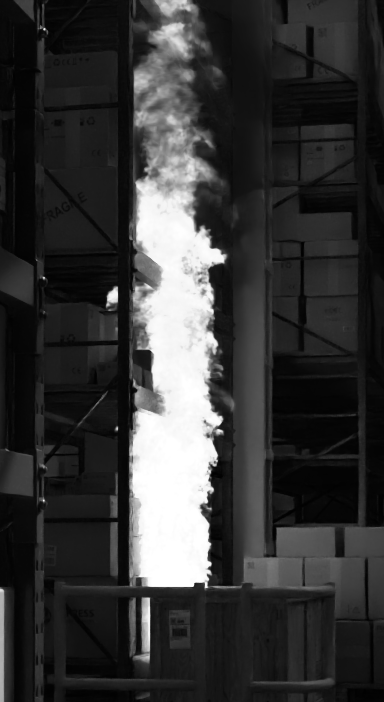

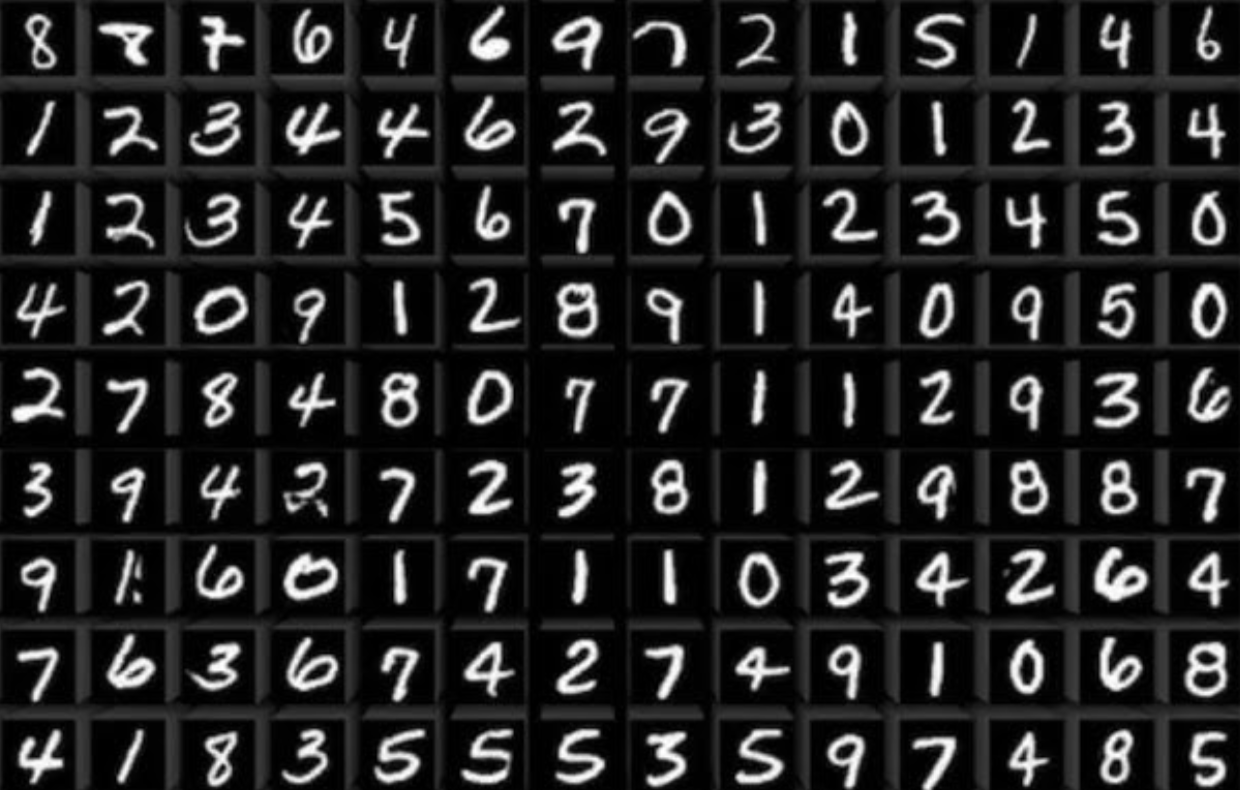

In [ ]:
api = cv2.imread("/content/CVL_Assignment02/fire2.png")
api_gt = cv2.imread("/content/CVL_Assignment02/fire2_GT.png")
mnist = cv2.imread("/content/CVL_Assignment02/mnist.png")
mnist_template = cv2.imread("/content/CVL_Assignment02/temp_image.png")
mnist_template2 = cv2.imread("/content/CVL_Assignment02/temp_image2.png")
mnist_template3 = cv2.imread("/content/CVL_Assignment02/temp_image3.png")

api_gray = cv2.cvtColor(api, cv2.COLOR_BGR2GRAY)
api_gt_gray = cv2.cvtColor(api_gt, cv2.COLOR_BGR2GRAY)
mnist_gray = cv2.cvtColor(mnist, cv2.COLOR_BGR2GRAY)
mnist_template_gray = cv2.cvtColor(mnist_template, cv2.COLOR_BGR2GRAY)
mnist_template_gray2 = cv2.cvtColor(mnist_template2, cv2.COLOR_BGR2GRAY)
mnist_template_gray3 = cv2.cvtColor(mnist_template3, cv2.COLOR_BGR2GRAY)
cv2_imshow(api_gray)
cv2_imshow(mnist_gray)

#Evaluasi Metode Detection
Pada tugas ini Saya akan mengimplementasikan beberapa metode object detection pada kasus tertentu. Untuk menilai performa deteksi, akan digunakan perhitungan evaluasi berikut:


*   IoU: menjelaskan seberapa baik lokasi yang diprediksi cocok dengan lokasi sebenarnya dengan menghitung seberapa besar bounding box yang diprediksi tumpang tindih dengan kotak ground truth. Dihitung dengan rumus area overlap/area union atau tp/(tp + fn + fp)
*   Accuracy: menghitung proporsi prediksi betul dari semua prediksi, dihitung dengan (tp + tn)/(tp + fp + tn + fn)
*   Precision: mengukur berapa persen model dapat dipercaya saat model membuat prediksi, pada sliding window terdapat banyak sekali window yang dikomputasi maka true negative akan mendominasi evaluasi, sedangkan precision hanya fokus pada kualitas masing-masing box yang terprediksi sehingga lebih cocok.













In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as _skimage_structural_similarity

def show_image(img1, img2, title1, title2, berwarna): #fungsi untuk display citra
  if berwarna == 1:
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) #matplotlib memproses citra menggunakan RGB, karena default pada notebook ini menggunakan BGR maka citra berwarna harus ditukar terlebih dahulu ke RGB
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

  fig, ax = plt.subplots(1,2, figsize=(10,5))

  ax[0].imshow(img1, cmap='gray', vmin=0, vmax=255)
  ax[0].set_title(title1),
  ax[0].axis("off")

  ax[1].imshow(img2, cmap='gray', vmin=0, vmax=255)
  ax[1].set_title(title2)
  ax[1].axis("off")
  plt.show()

def evaluasi(img, gt): #evaluasi untuk otsu
  tp = fp = tn = fn = 0
  for i in range(height_api):
    for j in range(width_api):
      if api_gt_gray[i, j] == 0 and image_segmented[i, j] == 0:
        tn += 1
      if api_gt_gray[i, j] == 0 and image_segmented[i, j] == 255:
        fn += 1
      if api_gt_gray[i, j] == 255 and image_segmented[i, j] == 0:
        fp += 1
      if api_gt_gray[i, j] == 255 and image_segmented[i, j] == 255:
        tp += 1

  conf_matrix = np.array([[tn, fp],
                         [fn, tp]])

  print("Confusion Matrix:")
  print(conf_matrix)
  iou = tp / (tp + fn + fp)
  acc = (tp + tn) / (tp + tn + fp + fn)
  print("iou: ", iou)
  print("akurasi: ", acc)

def iou1(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)

    boxAArea = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    boxBArea = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    iou = inter / float(boxAArea + boxBArea - inter)
    return iou

def evaluate_sliding_window(gt_df, detected_df): #evaluasi dan menghitung iou untuk sliding window
    tp = 0
    fp = 0
    fn = 0
    iou_threshold=0.5
    matched_gt = [False] * len(gt_df)
    matched_det = [False] * len(detected_df)

    for i, det_row in detected_df.iterrows():
        det_box = [det_row['xmin'], det_row['ymin'], det_row['xmax'], det_row['ymax']]
        best_iou = 0
        best_gt_idx = -1

        for j, gt_row in gt_df.iterrows():
            if not matched_gt[j]:
                gt_box = [gt_row['xmin'], gt_row['ymin'], gt_row['xmax'], gt_row['ymax']]
                iou = iou1(det_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

        if best_iou >= iou_threshold:
            tp += 1
            matched_gt[best_gt_idx] = True
            matched_det[i] = True
        else:
            fp += 1

    for j, matched in enumerate(matched_gt):
        if not matched:
            fn += 1
    tn= len(detected_df) - tp - fp - fn
    iou = tp / (tp + fn + fp)
    precision = tp / (tp + fp)
    return iou, precision, tp, fp, fn



#Segmentation (Otsu Method)
Secara teori, metode deteksi segmentation cocok diaplikasikan untuk kasus dimana objek bersifat homogen dan warnanya tidak terlalu bervariasi. Untuk menguji ini, Saya akan menggunakan metode adaptive segmentation Otsu pada dataset gudang terbakar untuk mensegmentasikan apinya sebagai foreground. Dataset juga memberikan ground truth dari output segmentasi api yang diharapkan, hasil deteksi api dari Otsu method akan dibandingkan dengan ground truth tersebut untuk memperoleh nilai IoU dan akurasinya untuk mengevaluasi performa Otsu method.

threshold oprimal:  128


/tmp/ipykernel_786/352833449.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  kernel_zero_padding[i+1, j+1] = si[i, j] #membuat 0 padding untuk image


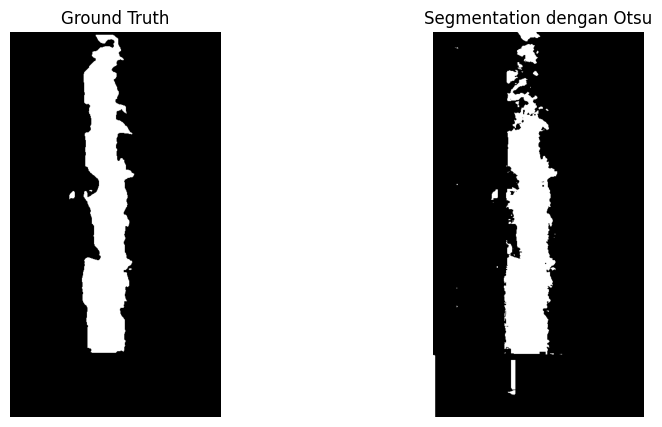

Confusion Matrix:
[[230243   4867]
 [  3649  30809]]
iou:  0.7834456452638271
akurasi:  0.9684087132003799


In [ ]:
def zero_padding(si):
  width = si.shape[1]
  height = si.shape[0]
  kernel_zero_padding = np.zeros((height + 2, width + 2), dtype=np.uint8)
  for i in range(height):
    for j in range (width):
      kernel_zero_padding[i+1, j+1] = si[i, j] #membuat 0 padding untuk image
  return kernel_zero_padding

def otsu_method(pixel_frequencies, height, width):
  threshold = 1
  threshold_list = []
  wvc_list = []

  wb_list = []
  wf_list = []
  mb_list = []
  mf_list = []
  vb_list = []
  vf_list = []
  jumlah_pixel = width*height

  while threshold < 256:
    a_weight = 0
    a_mean = 0
    b_weight = 0
    b_mean = 0
    a_variance = 0
    b_variance = 0
    for pixel_value in range(256):
    #background
      if pixel_value < threshold:
        a_weight = a_weight + pixel_frequencies[pixel_value]
        a_mean = a_mean + pixel_value * pixel_frequencies[pixel_value]
    #foreground
      else:
        b_weight = b_weight + pixel_frequencies[pixel_value]
        b_mean = b_mean + pixel_value * pixel_frequencies[pixel_value]

    weight_background = a_weight/jumlah_pixel
    weight_foreground = b_weight/jumlah_pixel
    mean_background = a_mean/a_weight if a_weight > 0 else 0
    mean_foreground = b_mean/b_weight if b_weight > 0 else 0

    for pixel_value in range(256):
    #background
      if pixel_value < threshold:
        a_variance = a_variance + (pixel_frequencies[pixel_value]*(pixel_value - mean_background)**2)
    #foreground
      else:
        b_variance = b_variance + (pixel_frequencies[pixel_value]*(pixel_value - mean_foreground)**2)
    variance_background = a_variance/a_weight if a_weight > 0 else 0
    variance_foreground = b_variance/b_weight if b_weight > 0 else 0

    wvc_dari_threshold = weight_background * variance_background + weight_foreground * variance_foreground
    threshold_list.append(threshold)
    wvc_list.append(wvc_dari_threshold)
    wb_list.append(weight_background)
    wf_list.append(weight_foreground)
    mb_list.append(mean_background)
    mf_list.append(mean_foreground)
    vb_list.append(variance_background)
    vf_list.append(variance_foreground)
    threshold = threshold + 1

  wvc_optimal = min(wvc_list)
  threshold_optimal_index = wvc_list.index(wvc_optimal)
  return threshold_optimal_index+1

def segment_image(threshold_optimal, image):
  width = image.shape[1]
  height = image.shape[0]
  image_segmented = np.zeros((height, width, 1), dtype=np.uint8)
  gray_image = image

  for i in range(height):
    for j in range (width):
      if gray_image[i,j] < threshold_optimal:
        image_segmented[i,j] = 0
      else:
        image_segmented[i, j] = 255

  zero_padded_segmented = zero_padding(image_segmented)
  return image_segmented, zero_padded_segmented


pixel_frequencies_hist, _ = np.histogram(api_gray.flatten(), bins=256, range=[0, 256])
pixel_frequencies = pixel_frequencies_hist.astype(np.int64)

height_api = api_gray.shape[0]
width_api = api_gray.shape[1]
threshold_optimal_api = otsu_method(pixel_frequencies, height_api, width_api)
print("threshold oprimal: ", threshold_optimal_api)

image_segmented, _ = segment_image(threshold_optimal_api, api_gray)
show_image(api_gt_gray, image_segmented, "Ground Truth", "Segmentation dengan Otsu", 0)
evaluasi(image_segmented, api_gt_gray)





Hasil segmentasi Otsu memberikan false positive (4,856) dan false negative (3,649) yang cukup banyak, namun performa Otsu Method dapat dibilang tetap cukup baik karena nilai true positivenya yang jauh lebih banyak (30,809). Selain itu, dengan nilai IoU (0.78344) dan akurasi (96.84%) yang sangat tinggi, dapat diasumsi bahwa Otsu Method merupakan metode object detection yang cukup efektif untuk kasus deteksi api.

#Sliding Window
Secara teori, metode deteksi sliding window cocok digunakan untuk objek yang memiliki bentuk homogen namun warna bervariasi, maka Saya akan mencoba mengaplikasikannya pada dataset MNIST untuk mencari angka 8. Saya akan menggunakan 3 template berbeda bersama dengan 3 nilai threshold sliding window yang berbeda untuk mencari model yang memberikan performa terbaik. Penggunaan algoritma machine learning akan terlalu kompleks untuk digunakan pada tugas ini, maka untuk menghemat waktu dan komputasi, Saya akan membandingkan tiap window dengan vector fitur edge dari template saja. Pipeline detilnya adalah:


*   Canny edge: mengaplikasikan canny edge (terdiri atas sobel edge detection, NMS, dan canny edge untuk konversi weak edge) pada template andka 8 dan citra MNIST untuk memperoleh edge map
*   Sliding window: edge map tiap window akan dibandingkan dengan edge map template menggunakan eucledian distance
*   Deteksi: Jika eucledian distance lebih rendah dari threshold tertentu maka akan dianggap bahwa terdapat angka 8 pada box tersebut
*   Iterasi: dilakukan untuk 3 template berbeda dan 3 threshold berbeda. IoU dan precision dari masing masing template dan threshold akan disimpan sebagai tabel





In [ ]:
#gaussian blur
import sys

def gaussian_blur(img, sigma):
  height, width = img.shape
  size = int(6 * sigma) #ukuran kernel semakin besar seiring dengan nilai sigma
  if size % 2 == 0:
      size += 1
  if size < 3:
      size = 3
  k = size//2

  kernel = np.zeros((size,size), dtype = np.float32)

  for i in range(size):
    for j in range(size):
      x = i - k
      y = j- k
      kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2)) #membuat kernel dinamik

  kernel /= np.sum(kernel)

  kernel_zero_padding = np.zeros((height + 2 * k, width + 2 * k), dtype=np.uint8)
  kernel_zero_padding[k:height+k, k:width+k] = img # membuat zero padding

  kernel_image = np.zeros((height, width), dtype=np.float32)

  for i in range(height):
     for j in range(width):
              region = kernel_zero_padding[i:i + size, j:j + size]
              cr = np.sum(region * kernel)
              if cr < 0:
                  cr = 0
              elif cr > 255:
                  cr = 255
              kernel_image[i, j] = cr
  return kernel_image.astype(np.uint8)

Gaussian blur akan diaplikasikan terlebih dahulu (dengan nilai sigma=1 karena merupakan hasil blurring yang paling optimal pada tugas CVL Saya sebelumnya) pada citra referensi (template) dan citra mnist untuk meminimalisir noise sehingga deteksi dapat dilakukan dengan lebih akurat.

In [ ]:
#canny edge
def sobel(img):
  img = img.astype(np.float32)
  height = img.shape[0]
  width = img.shape[1]
  sobel_x = np.array([[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]], dtype=np.float32)
  sobel_y = np.array([[-1, -2, -1],
                      [0, 0, 0],
                      [1, 2, 1]], dtype=np.float32)
  kernel_zero_padding = np.zeros((height + 2, width + 2), dtype=np.float32)
  kernel_zero_padding[1:height+1, 1:width+1] = img # zero padding

  x = np.zeros((height, width), dtype=np.float32)
  y = np.zeros((height, width), dtype=np.float32)
  for i in range(1, height + 1): #convolution
     for j in range(1, width + 1):
              region = kernel_zero_padding[i-1:i+2, j-1:j+2]
              x[i-1, j-1] = np.sum(region * sobel_x)
              y[i-1, j-1] = np.sum(region * sobel_y)

  magnitude = np.sqrt(x**2 + y**2)
  direction = np.arctan2(y, x)
  return magnitude, direction

def non_max_suppression(magnitude, direction):
    height, width = magnitude.shape
    nms = np.zeros_like(magnitude)
    angle = direction * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, height-1):
        for j in range(1, width-1):
            q = 255
            r = 255
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]
            elif (22.5 <= angle[i,j] < 67.5):
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]
            elif (67.5 <= angle[i,j] < 112.5):
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]
            elif (112.5 <= angle[i,j] < 157.5):
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]
            if (magnitude[i,j] >= q) and (magnitude[i,j] >= r):
                nms[i,j] = magnitude[i,j]
            else:
                nms[i,j] = 0
    return nms

def canny(img, t1, t2):
  height = img.shape[0]
  width = img.shape[1]
  edge_map = np.zeros((height, width),  dtype=np.uint8)
  for i in range(height):
    for j in range(width):
      if img[i, j] >= t1: #menentukan strong edge
        edge_map[i, j] = 2
      elif img[i, j] >= t2 and img[i, j] < t1:  #menentukan weak edge
        edge_map[i, j] = 1
      else:                                #menentukan non-edge
        edge_map[i, j] = 0

  a = True
  while a:        #mengubah weak edge yang benar menjadi strong edge
        a = False
        for i in range(height):
            for j in range(width):
                if edge_map[i, j] == 1:
                  if j+1<width and edge_map[i, j+1] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if j+1<width and i+1<height and edge_map[i+1, j+1] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if i+1<height and edge_map[i+1, j] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if i+1<height and j-1>=0 and edge_map[i+1, j-1] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if j-1>=0 and edge_map[i, j-1] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if i-1>=0 and j-1>=0 and edge_map[i-1, j-1] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if i-1>=0 and edge_map[i-1, j] == 2:
                    edge_map[i, j] = 2
                    a = True
                  if i-1>=0 and j+1<width and edge_map[i-1, j+1] == 2:
                    edge_map[i, j] = 2
                    a = True

  edge_map[edge_map == 2] = 255
  edge_map[edge_map != 255] = 0
  return edge_map

def canny_pipeline(img):
  img = gaussian_blur(img, 1)
  mag, dir = sobel(img)
  nms = non_max_suppression(mag, dir)

  median = np.median(mag[mag > 0]) #menentukan threshold t1 dan t2 untuk penentuan strong edge dan weak edge
  t1 = 1.33* median
  t2 = 0.66 * median
  edge_map = canny(nms, t1, t2)
  return edge_map

template_edge = canny_pipeline(mnist_template_gray)
template_edge2 = canny_pipeline(mnist_template_gray2)
template_edge3 = canny_pipeline(mnist_template_gray3)
image_edge = canny_pipeline(mnist_gray)

In [ ]:
#sliding window
def euclidean_distance(template_edge, window_edge): #menghitung eucledian distance
    diff = template_edge - window_edge
    squared_diff = diff ** 2
    distance = np.sqrt(np.sum(squared_diff))
    return distance

window = 75
height_mnist = mnist_gray.shape[0]
width_mnist = mnist_gray.shape[1]
stride = window+17
cropped = template_edge3[0:window, 0:window]

ground_truth = pd.DataFrame([
    {'xmin': 0, 'ymin': 0, 'xmax': window, 'ymax': window},
    {'xmin': stride, 'ymin': 0, 'xmax': stride+window, 'ymax': window},
    {'xmin': stride*6, 'ymin': stride*3, 'xmax': stride*6+window, 'ymax': stride*3+window},
    {'xmin': stride*2, 'ymin': stride*4, 'xmax': stride*2+window, 'ymax': stride*4+window},
    {'xmin': stride*4, 'ymin': stride*4, 'xmax': stride*4+window, 'ymax': stride*4+window},
    {'xmin': stride*7, 'ymin': stride*5, 'xmax': stride*7+window, 'ymax': stride*5+window},
    {'xmin': stride*11, 'ymin': stride*5, 'xmax': stride*11+window, 'ymax': stride*5+window},
    {'xmin': stride*12, 'ymin': stride*5, 'xmax': stride*12+window, 'ymax': stride*5+window},
    {'xmin': stride*13, 'ymin': stride*7, 'xmax': stride*13+window, 'ymax': stride*7+window},
    {'xmin': stride*2, 'ymin': stride*8, 'xmax': stride*2+window, 'ymax': stride*8+window},
    {'xmin': stride*12, 'ymin': stride*8, 'xmax': stride*12+window, 'ymax': stride*8+window}
])
print("ground truth:")
display(ground_truth)

hasil = []
templates = [
    ("template 1", template_edge),
    ("template 2", template_edge2),
    ("template 3", template_edge3),
]
thresholds = [25, 25.5, 26]

for t, template in templates: #iterasi untuk 3 threshold berbeda dengan 3 template berbeda
    for threshold in thresholds:
        detection = []
        for y in range(0, height_mnist - window, stride):
            for x in range(0, width_mnist - window, stride):
                window_edge = image_edge[y:y+window, x:x+window]
                distance = euclidean_distance(template, window_edge)
                if distance < threshold:
                    detection.append([x, y, x+window, y+window, distance])
        kk = pd.DataFrame(detection, columns=['xmin', 'ymin', 'xmax', 'ymax', 'distance'])
        iou, prec, tp, fp, fn = evaluate_sliding_window(ground_truth, kk)
        hasil.append([t, threshold, iou, prec, tp, fp, fn])

print("Hasil iou dan accuracy dari beberapa template:")
df1 = pd.DataFrame(hasil, columns=['template', 'threshold', 'iou', 'precision', 'True Positive', 'False Positive', 'False Negative'])
display(df1)

ground truth:


,xmin,ymin,xmax,ymax
0,0,0,75,75
1,92,0,167,75
2,552,276,627,351
3,184,368,259,443
4,368,368,443,443
5,644,460,719,535
6,1012,460,1087,535
7,1104,460,1179,535
8,1196,644,1271,719
9,184,736,259,811


Hasil iou dan accuracy dari beberapa template:


,template,threshold,iou,precision,True Positive,False Positive,False Negative
0,template 1,25.0,0.071429,0.250000,1,3,10
1,template 1,25.5,0.117647,0.250000,2,6,9
2,template 1,26.0,0.095238,0.166667,2,10,9
3,template 2,25.0,0.133333,0.333333,2,4,9
4,template 2,25.5,0.166667,0.300000,3,7,8
5,template 2,26.0,0.103448,0.142857,3,18,8
6,template 3,25.0,0.080000,0.125000,2,14,9
7,template 3,25.5,0.142857,0.190476,4,17,7
8,template 3,26.0,0.138889,0.166667,5,25,6


Berdasarkan hasil tersebut, dapat disimpulkan bahwa pipeline yang telah Saya pilih tampaknya kurang efektif untuk deteksi angka pada MNIST, bentuk angka pada dataset MNIST terlalu bervariasi untuk dideteksi pipeline ini dengan akurat, hal ini didukung dengan IoU dan precision yang rata-rata sangat rendah (tidak ada yang diatas 0.4). Template 2 tampaknya menghasilkan output IoU dan precision yang paling baik secara keseluruhan, template 2 dengan threshold=25 memberikan precision tertinggi (0.3333) dan template 2 dengan threshold=25.5 memberikan IoU tertinggi (0.1667). Untuk memperbaiki hal ini, mungkin ekstraksi fitur menggunakan HOG dan representasi GLCM akan menjadi parameter yang lebih efektif untuk dibandingkan daripada canny edge, selain itu perbedaan antara window dengan template mungkin dapat dihitung dengan metode yang lebih robust dari eucledian distance atau mungkin menggunakan SVM classifier untuk mendeteksi angka 8 pada tiap window saja.